# Código de treino do modelo de decisão de protocolo

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from joblib import dump, load

import os

import logging

np.random.seed(42)
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

print( os.getcwd() )

c:\Users\jcosta\Documents\gotham-iot-testbed\Dockerfiles\iot\building_monitor\models


In [2]:
# Load and preprocess dataset
try:
    df = pd.read_csv('../appliances_energy/energydata_complete.csv/energydata_complete.csv')
    logging.info("Dataset loaded successfully. Shape: %s", df.shape)
except FileNotFoundError:
    logging.error("Dataset 'energydata_complete.csv' not found.")
    sys.exit(1)

# Feature columns: every sensor reading in the CSV except the timestamp.
# IMPORTANT: this must keep the exact same order as the CSV columns, because
# client.py's telemetry loop feeds the decision model with `data_line[1:]`
# (every field after `date`, in CSV order) on each reading it publishes --
# see classify_security_level() in client.py. Do not reorder/select a subset
# here without updating client.py accordingly.
context_features = [c for c in df.columns if c != 'date']

df = pd.DataFrame(df)
#df.to_csv('../dataset/df_processed_original.csv', index=False)

2026-09-18 16:18:45,134 - INFO - Dataset loaded successfully. Shape: (19735, 29)


In [3]:
# --- Synthetic security-level labels ------------------------------------
#
# The public Appliances Energy Prediction dataset has no ground-truth label
# for "how much security this reading deserves" -- that judgement belongs to
# the thesis's own security policy, which isn't part of this dataset. As a
# placeholder target (to be replaced with your actual criticality criteria
# once defined), we derive a 3-level label from how far each reading sits
# from the "normal" operating envelope of the house: the more a reading
# deviates from the dataset's typical values, the higher the NIST security
# level it is assigned.
CRITICALITY_COLUMNS = ['Appliances', 'lights', 'T_out', 'RH_out', 'Windspeed']

# Security level -> TLS group. Must stay in sync with NIST_LEVEL_TO_TLS_GROUP
# in client.py (same keys, same order: 0=low ... 2=high).
NIST_LEVELS = {0: 'x25519', 1: 'mlkem768', 2: 'X25519MLKEM768'}


def generate_synthetic_labels(df, columns=CRITICALITY_COLUMNS):
    """Derive a 3-level (0/1/2) synthetic security-level label per row.

    The level is picked from the tercile (33rd/66th percentile) of a
    composite "how unusual is this reading" score: the mean absolute
    z-score across `columns`. Returns an int array aligned with df's rows:
    0=low -> x25519, 1=medium -> mlkem768, 2=high -> X25519MLKEM768 (see
    NIST_LEVELS above).
    """
    z_scores = (df[columns] - df[columns].mean()) / df[columns].std(ddof=0)
    criticality = z_scores.abs().mean(axis=1)

    low_cut, high_cut = criticality.quantile([1 / 3, 2 / 3])
    levels = pd.cut(criticality, bins=[-np.inf, low_cut, high_cut, np.inf], labels=[0, 1, 2])
    return levels.astype(int).to_numpy()

# Treino

In [4]:
y = generate_synthetic_labels(df)

X = df[context_features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

# Hyperparameter tuning. Kept small/shallow on purpose: this is a lightweight
# model meant to run on the edge node on every CSV row read (see
# classify_security_level() in client.py), so it needs to stay fast and
# cheap at inference time, not just accurate.
param_grid = {'n_estimators': [20, 50, 100], 'max_depth': [2, 3, 4], 'learning_rate': [0.05, 0.1, 0.2]}
classifier = GridSearchCV(XGBClassifier(random_state=42, eval_metric='mlogloss'), param_grid, cv=5, n_jobs=-1)
classifier.fit(X_train_scaled, y_train)
logging.info("Best classifier params: %s", classifier.best_params_)

# Save the trained model AND the fitted scaler. client.py's
# normalize_features() calls normalizer.transform(...) directly, so a fitted
# StandardScaler (which already exposes .transform()) works as-is, no
# conversion needed. File names match client.py's default MODEL_PATH /
# NORMALIZATION_PATH ("/decision_model.joblib" and "/normalization.joblib");
# copy these two files to the edge node's `/` (or point MODEL_PATH /
# NORMALIZATION_PATH at wherever you place them instead).
dump(classifier.best_estimator_, '../models/decision_model.joblib')
dump(scaler, '../models/normalization.joblib')

2026-09-18 16:18:58,364 - INFO - Best classifier params: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100}


['../models/normalization.joblib']

# Avaliação


Security Level Classification Report:
                precision    recall  f1-score   support

        x25519       0.94      0.97      0.95      1316
      mlkem768       0.90      0.90      0.90      1315
X25519MLKEM768       0.96      0.93      0.95      1316

      accuracy                           0.93      3947
     macro avg       0.93      0.93      0.93      3947
  weighted avg       0.93      0.93      0.93      3947



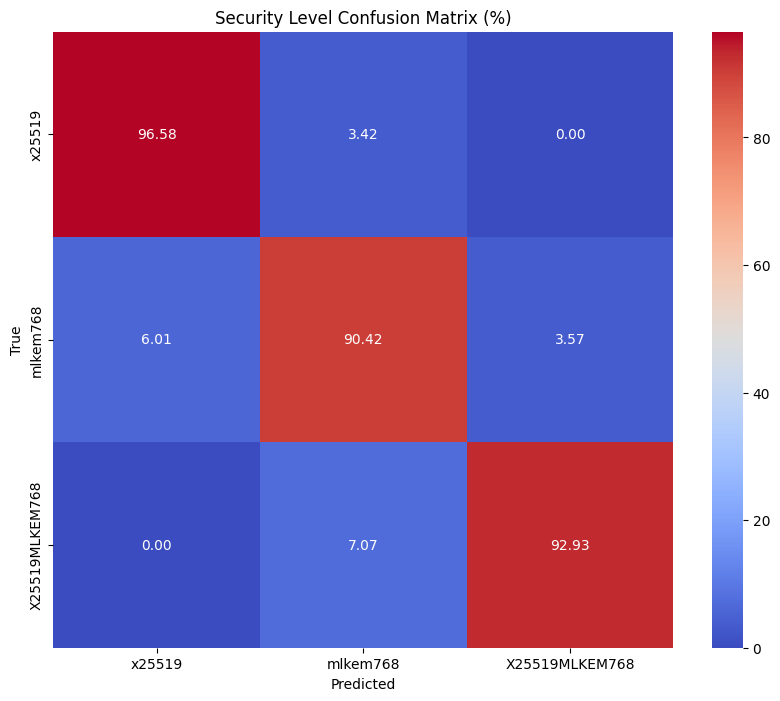

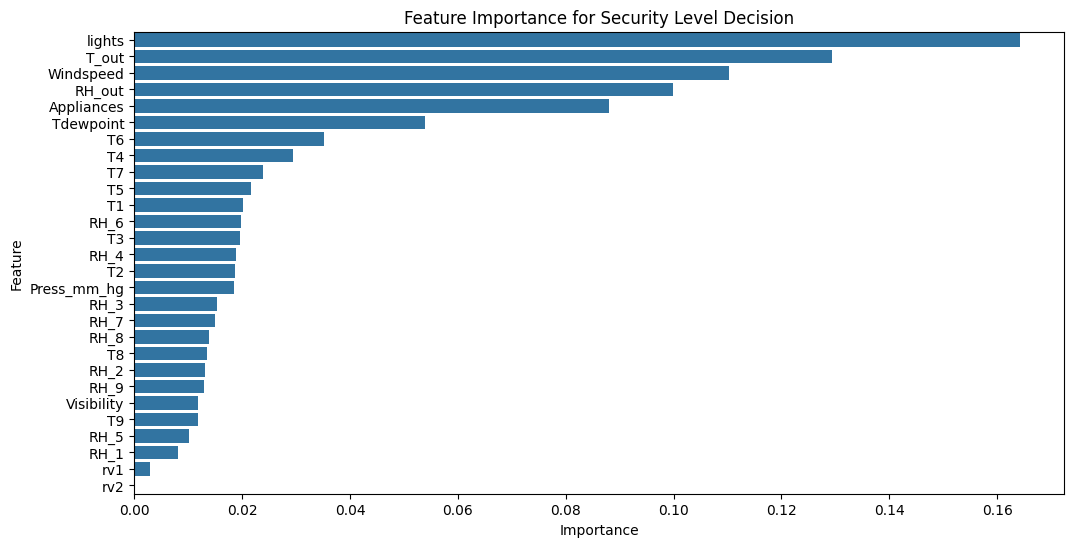

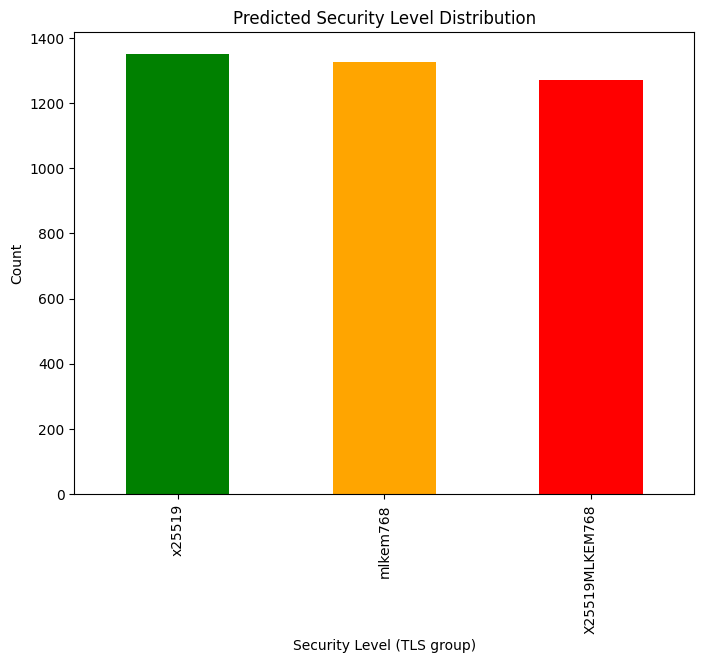

In [5]:
# Evaluate
y_pred = classifier.predict(X_test_scaled)
class_names = [NIST_LEVELS[i] for i in sorted(NIST_LEVELS)]

print("\nSecurity Level Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Graphs
cm = confusion_matrix(y_test, y_pred)
cm_percentage = cm / cm.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(10, 8))
sns.heatmap(cm_percentage, annot=True, fmt=".2f", cmap='coolwarm',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Security Level Confusion Matrix (%)')
plt.xlabel('Predicted')
plt.ylabel('True')
#plt.savefig("../models/figs/security_level_confusion.pdf")
plt.show()

feature_importance = pd.DataFrame({
    'Feature': context_features,
    'Importance': classifier.best_estimator_.feature_importances_,
}).sort_values('Importance', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance for Security Level Decision')
#plt.savefig("../models/figs/feature_importance.pdf")
plt.show()

level_counts = pd.Series([NIST_LEVELS[p] for p in y_pred]).value_counts()
plt.figure(figsize=(8, 6))
level_counts.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Predicted Security Level Distribution')
plt.xlabel('Security Level (TLS group)')
plt.ylabel('Count')
#plt.savefig("../models/figs/security_level_distribution.pdf")
plt.show()